# Core 01 — Linear Regression (Housing)

Industrial baseline: data generation, EDA, pipeline, diagnostics, coefficients.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42); sns.set_theme(style='whitegrid')


## 1) Dataset (synthetic but realistic)

In [2]:
n=3000
city=np.random.choice(['Rennes','Paris','Nantes','Lyon'], size=n, p=[0.35,0.25,0.25,0.15])
surface=np.clip(np.random.normal(65, 20, n), 18, 220)
rooms=np.clip((surface/18 + np.random.normal(0,0.8,n)).round().astype(int), 1, 9)
age=np.clip(np.random.exponential(18, n).round().astype(int), 0, 120)
dist=np.clip(np.random.gamma(2.1, 2.0, n), 0.2, 28)
parking=np.random.binomial(1, 0.58, n)
balcony=np.random.binomial(1, 0.44, n)
base={'Paris': 9800, 'Lyon': 5400, 'Rennes': 4400, 'Nantes': 4800}
ppm2=np.array([base[c] for c in city], dtype=float)
ppm2 = ppm2*(1-0.017*dist)*(1+0.055*balcony)*(1+0.045*parking)*(1-0.0022*age)
ppm2=np.clip(ppm2, 1800, None)
noise=np.random.normal(0, 22000, n)
price = surface*ppm2 + 10000*(rooms>=3) + noise
price=np.clip(price, 45000, None)
df=pd.DataFrame({'city':city,'surface_m2':surface,'rooms':rooms,'age_years':age,'dist_center_km':dist,'has_parking':parking,'has_balcony':balcony,'price_eur':price})
df.head()


,city,surface_m2,rooms,age_years,dist_center_km,has_parking,has_balcony,price_eur
0,Paris,86.198728,5,9,0.271963,0,0,823873.719190
1,Lyon,77.340119,5,5,1.329861,1,0,410314.703970
2,Nantes,78.671386,5,35,2.327190,1,0,372915.686065
3,Paris,37.680886,3,22,2.286970,1,1,423733.285532
4,Rennes,89.238880,5,14,9.250806,1,1,337888.112357


## 2) EDA

In [3]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,3000,4,Rennes,1052,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surface_m2,3000.0,NaN,NaN,NaN,64.669065,19.834797,18.0,50.846057,64.756034,78.034361,143.524754
rooms,3000.0,NaN,NaN,NaN,3.594333,1.384825,1.0,3.0,4.0,5.0,9.0
age_years,3000.0,NaN,NaN,NaN,18.122667,18.249109,0.0,5.0,12.0,25.0,120.0
dist_center_km,3000.0,NaN,NaN,NaN,4.240752,2.859804,0.2,2.120428,3.579259,5.691703,19.34707
has_parking,3000.0,NaN,NaN,NaN,0.552,0.497372,0.0,0.0,1.0,1.0,1.0
has_balcony,3000.0,NaN,NaN,NaN,0.430333,0.495205,0.0,0.0,0.0,1.0,1.0
price_eur,3000.0,NaN,NaN,NaN,366914.922193,179693.057882,45000.0,248025.36559,326651.787744,436989.704357,1120721.061655


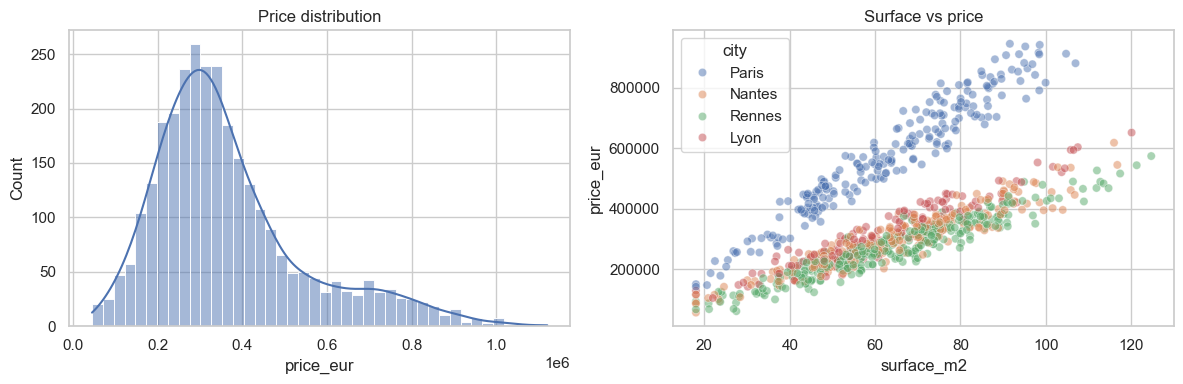

In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['price_eur'], kde=True, ax=ax[0]); ax[0].set_title('Price distribution')
sns.scatterplot(data=df.sample(900, random_state=1), x='surface_m2', y='price_eur', hue='city', alpha=0.5, ax=ax[1]); ax[1].set_title('Surface vs price')
plt.tight_layout(); plt.show()


## 3) Pipeline + evaluation

In [5]:
X=df.drop(columns=['price_eur']); y=df['price_eur']
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.2,random_state=42)
cat=['city']; num=[c for c in X.columns if c not in cat]
pre=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),cat),('num','passthrough',num)])
pipe=Pipeline([('pre',pre),('model',Ridge(alpha=2.0, random_state=42))])
pipe.fit(Xtr,ytr)
pred=pipe.predict(Xte)
mae=mean_absolute_error(yte,pred); rmse=mean_squared_error(yte,pred,squared=False); r2=r2_score(yte,pred)
pd.DataFrame({'MAE':[mae],'RMSE':[rmse],'R2':[r2]})


,MAE,RMSE,R2
0,34344.961592,46262.909852,0.936413


## 4) Residual diagnostics

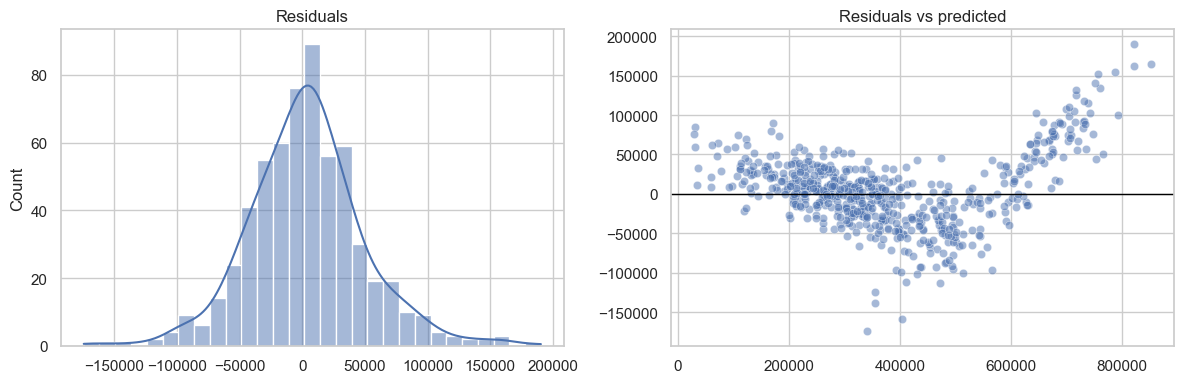

In [6]:
res=yte.values-pred
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(res,kde=True,ax=ax[0]); ax[0].set_title('Residuals')
sns.scatterplot(x=pred,y=res,alpha=0.5,ax=ax[1]); ax[1].axhline(0,color='black',lw=1); ax[1].set_title('Residuals vs predicted')
plt.tight_layout(); plt.show()


## 5) Coefficients (interpretability)

In [7]:
ohe=pipe.named_steps['pre'].named_transformers_['cat']
feat=ohe.get_feature_names_out(cat).tolist()+num
coef=pipe.named_steps['model'].coef_
imp=pd.DataFrame({'feature':feat,'coef':coef}).sort_values('coef', key=lambda s: s.abs(), ascending=False)
imp.head(15)


,feature,coef
2,city_Paris,218003.985590
3,city_Rennes,-99797.200981
1,city_Nantes,-78116.228653
0,city_Lyon,-40090.555956
9,has_balcony,19866.395591
8,has_parking,12684.408014
7,dist_center_km,-5946.465863
4,surface_m2,5615.315768
5,rooms,1904.418111
6,age_years,-720.924330


## Conclusion
Baseline solide et interprétable, prêt pour upgrades (quantile regression, geo features, robust losses).